# SIPARTA: RANCANG BANGUN ALAT DETEKSI DAN PERINGATAN DINI GAS BERACUN DARI REAKSI KIMIA RUMAH TANGGA BERBASIS JARINGAN SARAF TIRUAN

Notebook ini adalah **Pipeline AI Terintegrasi** untuk SIPARTA. Alur ini menggabungkan fondasi teoretis (kimiawi) dan implementasi aktual (sensor fisik IoT).

### Alur Pipeline
1. **Fase 1: Proof of Concept (Teori Kimia)**
   Membangun dan melatih model jaringan saraf tiruan (JST) berdasarkan 10 parameter teoretis kimia (pH, konsentrasi, dll). Fase ini membuktikan bahwa risiko pencampuran bahan kimia rumah tangga dapat diklasifikasikan dengan JST.
2. **Fase 2: Translasi Sensor Fisik (Edge-AI IoT)**
   Membangun JST berarsitektur ringan untuk dijalankan di Edge (Raspberry Pi), menggunakan 4 parameter input dari sensor aktual (MQ-2, MQ-135, TGS2600, MiCS-5524).
   *Catatan Audit:* Mengikuti prinsip integritas data, jika data IoT aktual tidak mencukupi, sistem akan memberikan status `DATA_UNAVAILABLE` dan menolak untuk melatih model fisik menggunakan data rekayasa.
3. **Fase 3: Simulasi Inference (TFLite)**
   Validasi model tflite pada environment hardware.

## 1. Persiapan & Import Library

In [179]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow Version: {tf.__version__}")

# Reprodusibilitas
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow Version: 2.21.0


---
## FASE 1: PROOF OF CONCEPT (Teori Reaksi Kimia)

Mempertahankan konsep awal pencampuran gas kimia. Model dilatih dengan 10 fitur teoretis untuk membuktikan logika klasifikasi risiko.

In [180]:
# Definisi bahan kimia rumah tangga
BAHAN_KIMIA = {
    0: {'nama': 'Pemutih (NaClO)',       'pH': 12.5, 'konsentrasi_default': 5.0},
    1: {'nama': 'Amonia (NH3)',           'pH': 11.5, 'konsentrasi_default': 10.0},
    2: {'nama': 'Cuka (CH3COOH)',         'pH': 2.5,  'konsentrasi_default': 5.0},
    3: {'nama': 'Sabun Cuci Piring',      'pH': 7.0,  'konsentrasi_default': 15.0},
    4: {'nama': 'Pembersih Lantai (HCl)', 'pH': 1.0,  'konsentrasi_default': 10.0},
    5: {'nama': 'Air (H2O)',              'pH': 7.0,  'konsentrasi_default': 100.0},
    6: {'nama': 'Alkohol (Etanol)',       'pH': 7.0,  'konsentrasi_default': 70.0},
    7: {'nama': 'Basa Kuat (NaOH)',       'pH': 14.0, 'konsentrasi_default': 20.0},
    8: {'nama': 'Aluminium Foil (Al)',    'pH': 7.0,  'konsentrasi_default': 100.0},
    9: {'nama': 'Asap Pembakaran (CO)',   'pH': 7.0,  'konsentrasi_default': 10.0},
    10: {'nama': 'Gas LPG (Propana/Butana)','pH': 7.0, 'konsentrasi_default': 100.0},
}

RISIKO_CAMPURAN = {
    (0, 1): 2,  # Pemutih + Amonia   -> Gas Kloramin (TINGGI)
    (0, 2): 2,  # Pemutih + Cuka     -> Gas Klorin (TINGGI)
    (0, 4): 2,  # Pemutih + HCl      -> Gas Klorin (TINGGI)
    (0, 6): 2,  # Pemutih + Alkohol  -> Kloroform (TINGGI)
    (7, 8): 2,  # Basa Kuat + Aluminium -> Gas Hidrogen & Eksotermik ledakan (TINGGI)
    (5, 9): 2,  # Air + Asap (CO)    -> Deteksi Anomali CO (TINGGI)
    (5, 10): 2, # Air + Gas LPG      -> Kebocoran Propana/Butana (TINGGI)
    (1, 2): 1,  # Amonia + Cuka      -> Amonium Asetat (SEDANG)
    (1, 4): 1,  # Amonia + HCl       -> Amonium Klorida asap (SEDANG)
    (2, 4): 1,  # Cuka + HCl         -> Campuran asam (SEDANG)
    (2, 3): 1,  # Cuka + Sabun       -> Netralkan surfaktan (SEDANG)
    (0, 3): 1,  # Pemutih + Sabun    -> Potensi gas klorin ringan (SEDANG)
    (0, 5): 0,  # Pemutih + Air      -> Encer (AMAN)
    (1, 5): 0,  # Amonia + Air       -> Encer (AMAN)
    (2, 5): 0,  # Cuka + Air         -> Encer (AMAN)
    (3, 5): 0,  # Sabun + Air        -> Normal (AMAN)
    (4, 5): 0,  # HCl + Air          -> Encer (AMAN)
    (3, 4): 0,  # Sabun + HCl        -> Umumnya aman (AMAN)
    (1, 3): 0,  # Amonia + Sabun     -> Umumnya aman (AMAN)
    (5, 6): 0,  # Alkohol + Air      -> Encer (AMAN)
}

print(f"Jumlah bahan terdaftar: {len(BAHAN_KIMIA)}")

Jumlah bahan terdaftar: 11


In [186]:
# Fungsi generator dataset teoretis
def generate_theoretical_dataset(n_samples=3000, seed=42):
    rng = np.random.RandomState(seed)
    records = []
    kombinasi_list = list(RISIKO_CAMPURAN.keys())
    
    for _ in range(n_samples):
        bahan_1, bahan_2 = kombinasi_list[rng.randint(0, len(kombinasi_list))]
        info_1, info_2 = BAHAN_KIMIA[bahan_1], BAHAN_KIMIA[bahan_2]
        
        konsentrasi_1 = max(0.5, info_1['konsentrasi_default'] + rng.normal(0, 2))
        konsentrasi_2 = max(0.5, info_2['konsentrasi_default'] + rng.normal(0, 2))
        pH_1 = info_1['pH'] + rng.normal(0, 0.3)
        pH_2 = info_2['pH'] + rng.normal(0, 0.3)
        
        suhu_ruangan = rng.uniform(20, 40)
        ventilasi = rng.uniform(0, 1)
        volume_campuran = rng.uniform(50, 500)
        delta_pH = abs(pH_1 - pH_2)
        
        risiko_score = RISIKO_CAMPURAN[(bahan_1, bahan_2)]
        
        # Modifiers
        if konsentrasi_1 > info_1['konsentrasi_default'] * 1.3 and risiko_score > 0:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.7, 0.3]))
        if suhu_ruangan > 35 and risiko_score >= 1:
            risiko_score = min(2, risiko_score + rng.choice([0, 1], p=[0.6, 0.4]))
        if ventilasi > 0.8 and risiko_score == 1:
            risiko_score = max(0, risiko_score - rng.choice([0, 1], p=[0.6, 0.4]))
            
        if rng.random() < 0.03:
            risiko_score = rng.choice([0, 1, 2])
            
        records.append({
            'bahan_1': bahan_1, 'bahan_2': bahan_2,
            'pH_bahan_1': round(pH_1, 2), 'pH_bahan_2': round(pH_2, 2),
            'delta_pH': round(delta_pH, 2),
            'konsentrasi_1': round(konsentrasi_1, 2), 'konsentrasi_2': round(konsentrasi_2, 2),
            'suhu_ruangan': round(suhu_ruangan, 2), 'ventilasi': round(ventilasi, 4),
            'volume_campuran_ml': round(volume_campuran, 1),
            'tingkat_risiko': int(risiko_score),
        })
    return pd.DataFrame(records)

df = generate_theoretical_dataset(3000)
print(f"[STATUS] Dataset teoretis berhasil dibuat: {df.shape[0]} sampel.")
display(df.head())

[STATUS] Dataset teoretis berhasil dibuat: 3000 sampel.


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
0,5,10,7.14,7.41,0.27,98.90,101.03,28.92,0.1000,256.7,2
1,1,2,11.33,2.22,9.11,8.84,3.95,30.50,0.4319,181.1,1
2,2,4,2.06,1.45,0.61,4.50,9.67,39.66,0.4668,437.0,2
3,3,4,7.09,0.81,6.28,13.80,11.89,28.80,0.1220,272.8,0
4,1,5,11.37,7.46,3.91,7.61,99.18,24.16,0.5677,64.1,0


In [187]:
# ============================================================
# Tambahkan kolom nama bahan (untuk eksplorasi)
# ============================================================
df['nama_bahan_1'] = df['bahan_1'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['nama_bahan_2'] = df['bahan_2'].map(lambda x: BAHAN_KIMIA[x]['nama'])
df['campuran'] = df['nama_bahan_1'] + ' + ' + df['nama_bahan_2']
df['label_risiko'] = df['tingkat_risiko'].map({0: 'Aman', 1: 'Sedang', 2: 'Tinggi'})

print("\nContoh data dengan nama bahan:")
df[['campuran', 'pH_bahan_1', 'pH_bahan_2', 'delta_pH',
    'konsentrasi_1', 'suhu_ruangan', 'ventilasi', 'label_risiko']].head(10)


Contoh data dengan nama bahan:


,campuran,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,suhu_ruangan,ventilasi,label_risiko
0,Air (H2O) + Gas LPG (Propana/Butana),7.14,7.41,0.27,98.90,28.92,0.1000,Tinggi
1,Amonia (NH3) + Cuka (CH3COOH),11.33,2.22,9.11,8.84,30.50,0.4319,Sedang
2,Cuka (CH3COOH) + Pembersih Lantai (HCl),2.06,1.45,0.61,4.50,39.66,0.4668,Tinggi
3,Sabun Cuci Piring + Pembersih Lantai (HCl),7.09,0.81,6.28,13.80,28.80,0.1220,Aman
4,Amonia (NH3) + Air (H2O),11.37,7.46,3.91,7.61,24.16,0.5677,Aman
5,Pemutih (NaClO) + Sabun Cuci Piring,12.47,6.91,5.56,6.48,27.77,0.2713,Sedang
6,Pemutih (NaClO) + Air (H2O),12.30,7.18,5.11,5.65,20.11,0.8155,Aman
7,Pemutih (NaClO) + Amonia (NH3),12.70,11.57,1.13,6.40,37.00,0.4495,Tinggi
8,Basa Kuat (NaOH) + Aluminium Foil (Al),13.98,7.30,6.68,21.63,22.39,0.7132,Tinggi
9,Amonia (NH3) + Air (H2O),11.38,6.98,4.40,16.74,22.16,0.0314,Aman


In [188]:
# ============================================================
# Simpan dataset ke CSV (opsional - untuk digunakan kembali)
# ============================================================
df.to_csv('dataset_gas_beracun_siparta.csv', index=False)
print("\u2705 Dataset tersimpan: dataset_gas_beracun_siparta.csv")

✅ Dataset tersimpan: dataset_gas_beracun_siparta.csv


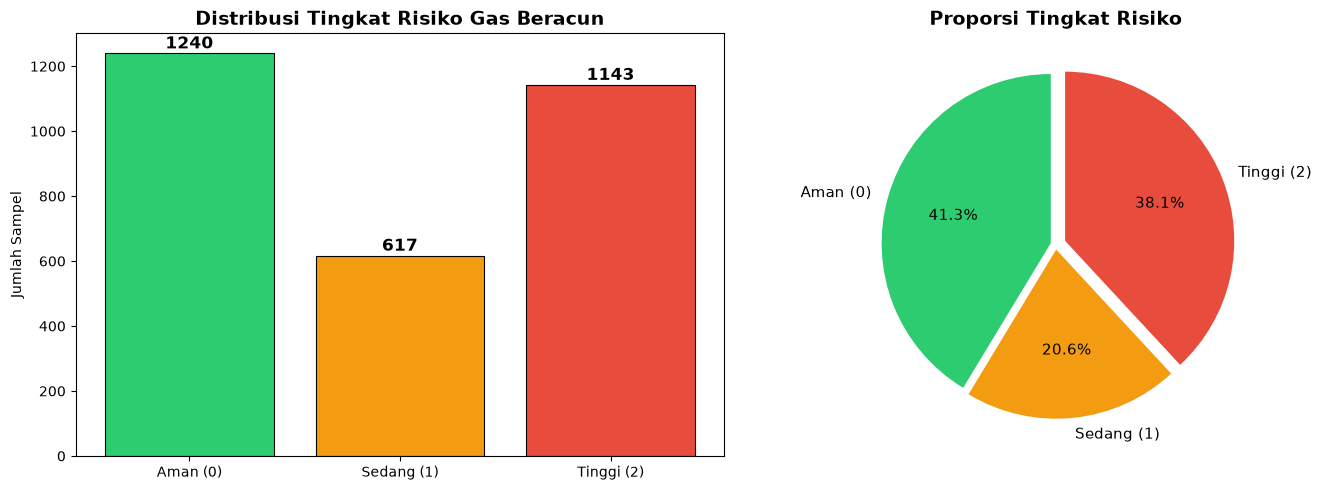

In [189]:
# ============================================================
# Distribusi Tingkat Risiko
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
risk_counts = df['tingkat_risiko'].value_counts().sort_index()
risk_labels = ['Aman (0)', 'Sedang (1)', 'Tinggi (2)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(risk_labels, risk_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Tingkat Risiko Gas Beracun', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 15, str(val),
                ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.03, 0.03, 0.06],
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Tingkat Risiko', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

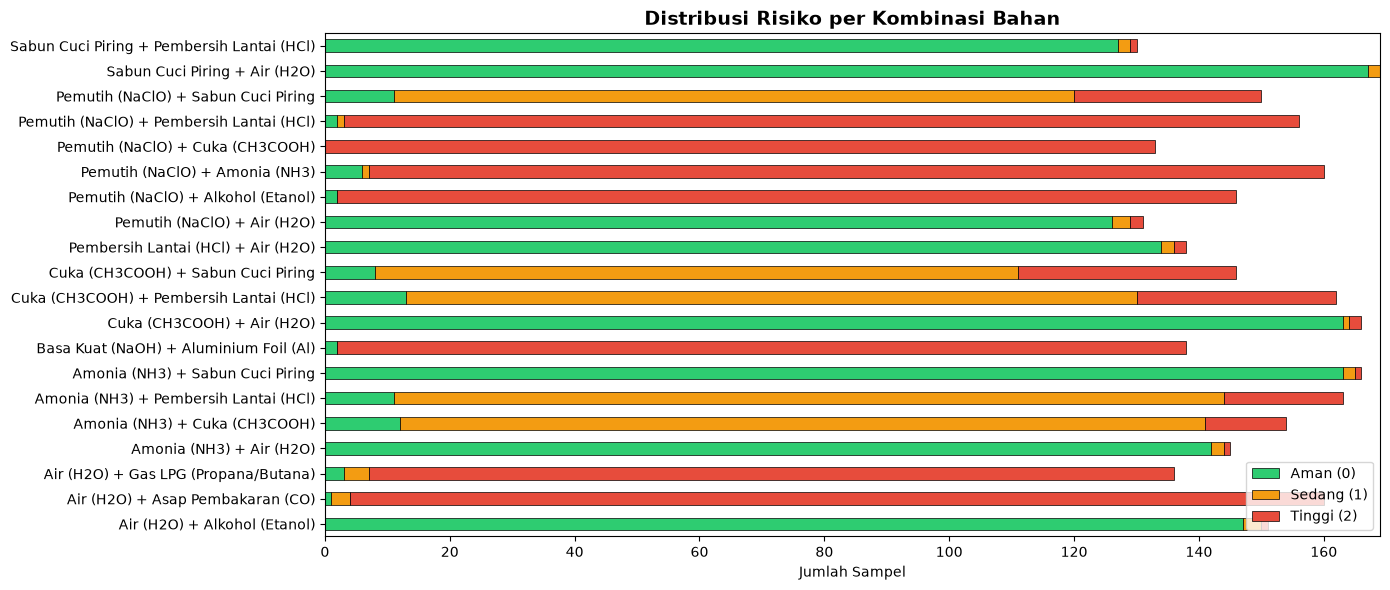

In [190]:
# ============================================================
# Risiko per Kombinasi Bahan
# ============================================================
risk_by_mix = df.groupby(['campuran', 'tingkat_risiko']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
risk_by_mix.plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Risiko per Kombinasi Bahan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Sampel')
ax.set_ylabel('')
ax.legend(['Aman (0)', 'Sedang (1)', 'Tinggi (2)'], loc='lower right')
plt.tight_layout()
plt.show()

In [194]:
# ============================================================
# Informasi Dataset
# ============================================================
print("=" * 60)
print("INFORMASI DATASET SIPARTA")
print("=" * 60)
print(f"Jumlah sampel  : {df.shape[0]}")
print(f"Jumlah fitur   : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTipe data:")
print(df.dtypes)
print(f"\nStatistik deskriptif:")
df.describe()

INFORMASI DATASET SIPARTA
Jumlah sampel  : 3000
Jumlah fitur   : 15
Missing values : 0

Tipe data:
bahan_1                 int64
bahan_2                 int64
pH_bahan_1            float64
pH_bahan_2            float64
delta_pH              float64
konsentrasi_1         float64
konsentrasi_2         float64
suhu_ruangan          float64
ventilasi             float64
volume_campuran_ml    float64
tingkat_risiko          int64
nama_bahan_1              str
nama_bahan_2              str
campuran                  str
label_risiko              str
dtype: object

Statistik deskriptif:


,bahan_1,bahan_2,pH_bahan_1,pH_bahan_2,delta_pH,konsentrasi_1,konsentrasi_2,suhu_ruangan,ventilasi,volume_campuran_ml,tingkat_risiko
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.075333,4.665000,8.883160,5.586823,4.862993,22.107180,46.833113,30.057707,0.502774,272.894400,0.967667
std,2.036592,2.218802,4.094169,2.904480,3.491779,32.920662,42.026482,5.838711,0.289358,129.556452,0.890816
min,0.000000,1.000000,0.220000,0.150000,0.000000,0.500000,0.500000,20.000000,0.000200,50.000000,0.000000
25%,0.000000,3.000000,6.760000,2.457500,1.175000,5.110000,9.877500,24.915000,0.250400,164.300000,0.000000
50%,1.000000,4.000000,11.260000,6.850000,4.950000,8.690000,15.635000,30.175000,0.505150,269.850000,1.000000
75%,3.000000,5.000000,12.350000,7.140000,6.570000,14.685000,98.642500,35.160000,0.751975,386.500000,2.000000
max,7.000000,10.000000,14.900000,12.190000,12.440000,105.810000,105.450000,40.000000,0.999500,499.800000,2.000000


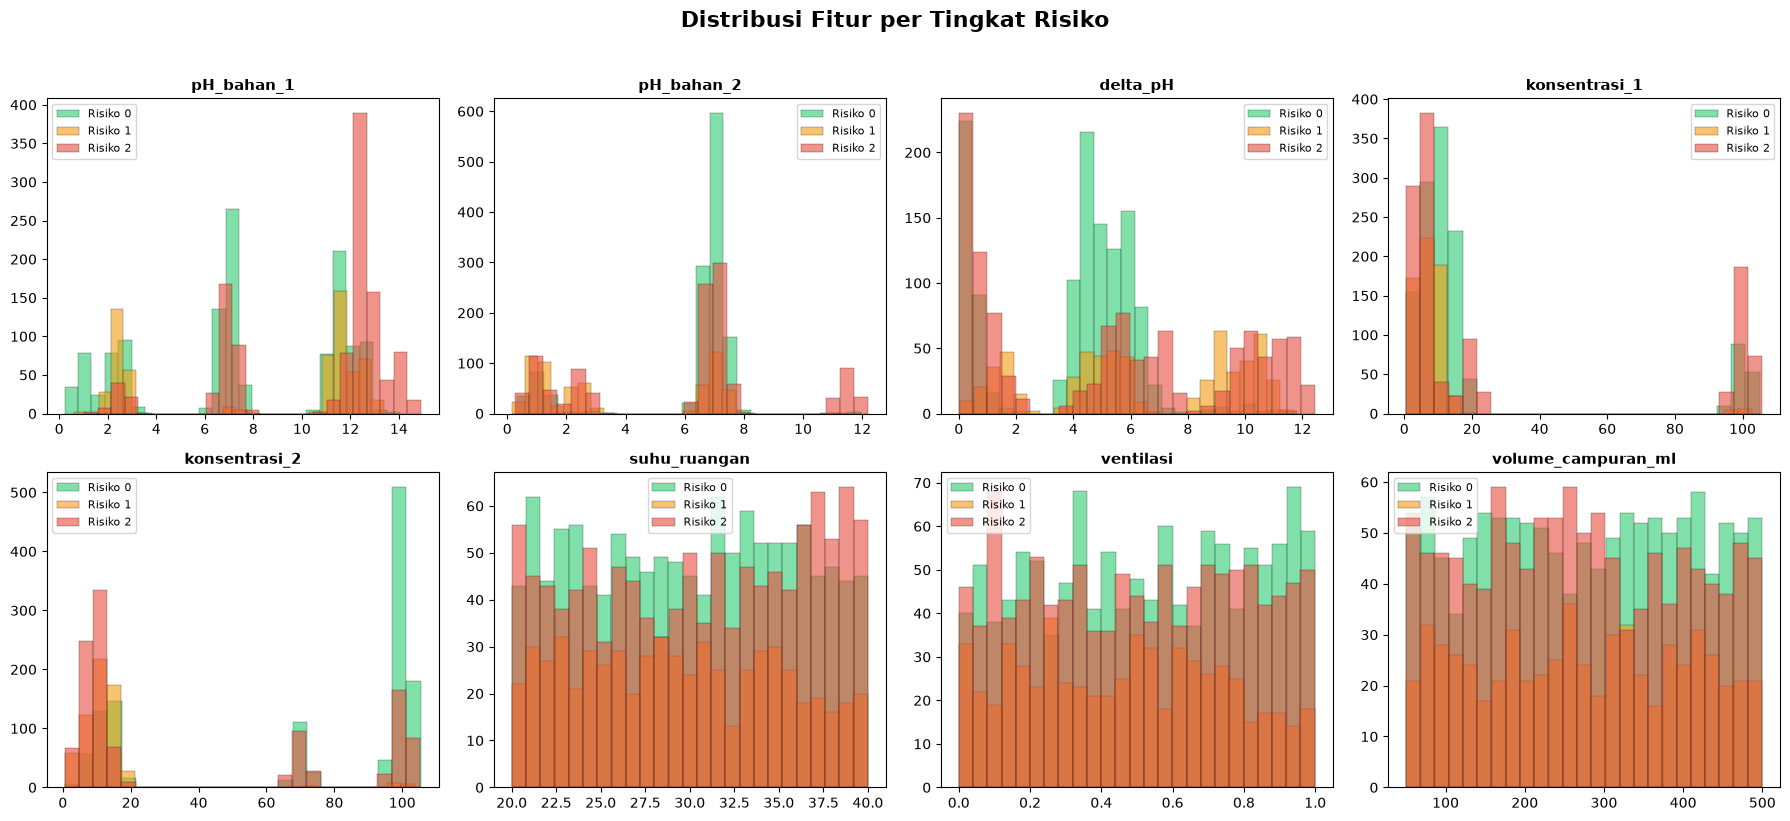

In [195]:
# ============================================================
# Distribusi fitur numerik berdasarkan tingkat risiko
# ============================================================
fitur_numerik = ['pH_bahan_1', 'pH_bahan_2', 'delta_pH', 'konsentrasi_1',
                 'konsentrasi_2', 'suhu_ruangan', 'ventilasi', 'volume_campuran_ml']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    for risk_level, color in zip([0, 1, 2], colors):
        data = df[df['tingkat_risiko'] == risk_level][col]
        axes[i].hist(data, bins=25, alpha=0.6, color=color, label=f'Risiko {risk_level}',
                    edgecolor='black', linewidth=0.3)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Tingkat Risiko', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

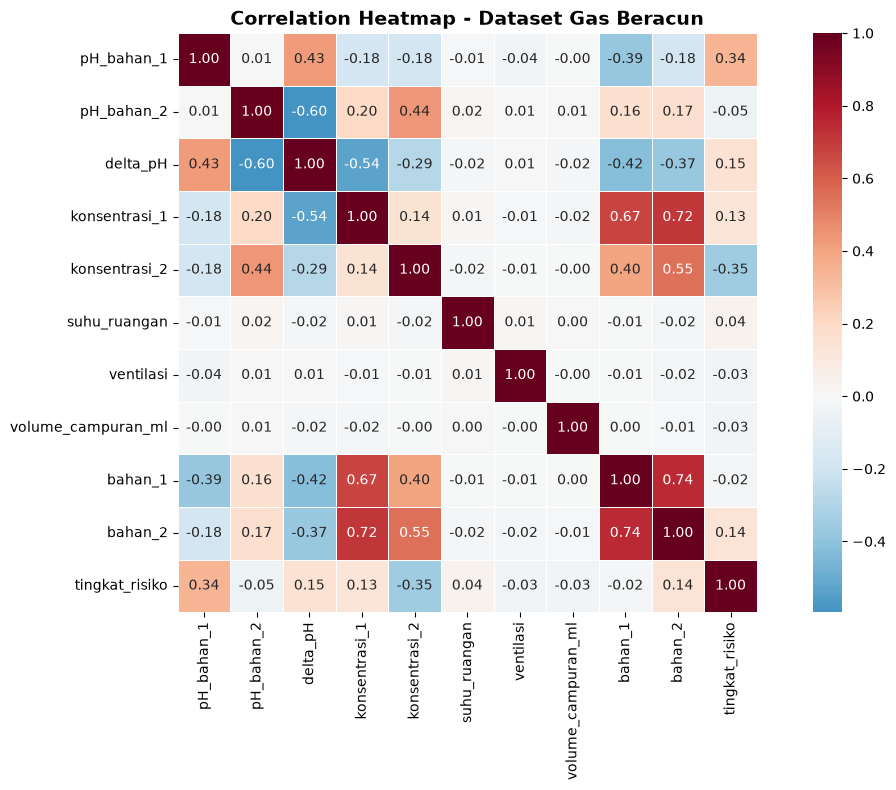

In [196]:
# ============================================================
# Correlation Heatmap
# ============================================================
fitur_korelasi = fitur_numerik + ['bahan_1', 'bahan_2', 'tingkat_risiko']

plt.figure(figsize=(12, 8))
corr = df[fitur_korelasi].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Dataset Gas Beracun', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Preprocessing & Model Pelatihan (Fase 1)
FEATURE_COLUMNS = ['bahan_1', 'bahan_2', 'pH_bahan_1', 'pH_bahan_2', 'delta_pH', 
                   'konsentrasi_1', 'konsentrasi_2', 'suhu_ruangan', 'ventilasi', 'volume_campuran_ml']
X = df[FEATURE_COLUMNS].values
y = df['tingkat_risiko'].values
NUM_CLASSES = 3  # Aman, Sedang, Tinggi

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y_theory)
scaler_th = StandardScaler()
X_tr_sc = scaler_th.fit_transform(X_tr)
X_te_sc = scaler_th.transform(X_te)
y_tr_cat = to_categorical(y_tr, 3)
y_te_cat = to_categorical(y_te, 3)

model_theory = Sequential([
    Input(shape=(10,)),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(3, activation='softmax')
], name='SIPARTA_THEORY')

model_theory.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_th = model_theory.fit(X_tr_sc, y_tr_cat, validation_split=0.2, epochs=30, batch_size=32, verbose=0)
loss, acc = model_theory.evaluate(X_te_sc, y_te_cat, verbose=0)
print(f"[STATUS] Pelatihan Fase 1 Selesai. Test Accuracy: {acc*100:.2f}%")

[STATUS] Pelatihan Fase 1 Selesai. Test Accuracy: 93.50%


In [202]:
# ============================================================
# Split data: Train (70%), Validation (15%), Test (15%)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Training set   : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} sampel ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set   : 2100 sampel (70.0%)
Validation set : 450 sampel (15.0%)
Test set       : 450 sampel (15.0%)


In [203]:
# ============================================================
# Feature Scaling (StandardScaler)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\u2705 Feature scaling selesai (StandardScaler)")
print(f"   Mean training (sesudah): {X_train_scaled.mean():.6f}")
print(f"   Std training (sesudah) : {X_train_scaled.std():.6f}")

✅ Feature scaling selesai (StandardScaler)
   Mean training (sesudah): 0.000000
   Std training (sesudah) : 1.000000


In [ ]:
# ============================================================
# One-Hot Encoding target (untuk multi-class classification)
# ============================================================
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\u2705 One-hot encoding selesai")
print(f"   y_train shape: {y_train_cat.shape}")
print(f"   Contoh: {y_train[:5]} -> ")
print(f"           {y_train_cat[:5]}")

In [ ]:
# ============================================================
# Hyperparameter
# ============================================================
INPUT_DIM = X_train_scaled.shape[1]
LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 32

print(f"Input dimension : {INPUT_DIM}")
print(f"Output classes  : {NUM_CLASSES}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Epochs          : {EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")

In [ ]:
# ============================================================
# Bangun Model JST
# ============================================================
def build_ann_model(input_dim, num_classes, learning_rate=0.001):
    """
    Membangun arsitektur JST untuk klasifikasi tingkat risiko
    gas beracun dari reaksi kimia rumah tangga.

    Args:
        input_dim: Jumlah fitur input
        num_classes: Jumlah kelas output (3: Aman/Sedang/Tinggi)
        learning_rate: Learning rate untuk optimizer Adam

    Returns:
        model: Compiled Keras Sequential model
    """
    model = Sequential(name='SIPARTA_JST')

    # Input + Hidden Layer 1
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(128, activation='relu', kernel_initializer='he_normal', name='hidden_1'))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(0.3, name='dropout_1'))

    # Hidden Layer 2
    model.add(Dense(64, activation='relu', kernel_initializer='he_normal', name='hidden_2'))
    model.add(BatchNormalization(name='bn_2'))
    model.add(Dropout(0.3, name='dropout_2'))

    # Hidden Layer 3
    model.add(Dense(32, activation='relu', kernel_initializer='he_normal', name='hidden_3'))
    model.add(BatchNormalization(name='bn_3'))
    model.add(Dropout(0.2, name='dropout_3'))

    # Output Layer (3 kelas: Aman, Sedang, Tinggi)
    model.add(Dense(num_classes, activation='softmax', name='output'))

    # Compile
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Buat model
model = build_ann_model(INPUT_DIM, NUM_CLASSES, LEARNING_RATE)

# Tampilkan arsitektur
model.summary()

In [ ]:
# Visualisasi arsitektur model
tf.keras.utils.plot_model(
    model,
    to_file='siparta_ann_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=100
)

---
## FASE 2: TRANSLASI SENSOR FISIK (IoT Edge-AI)

Model Phase 1 memiliki input 10 variabel kimiawi yang tidak dapat diukur secara real-time oleh hardware (yang memiliki 4 sensor gas: MQ-2, MQ-135, TGS2600, MiCS-5524). 
Fase 2 merupakan proses di mana kita melatih model khusus Edge-AI (12,739 parameter maksimum) menggunakan data **IoT empiris**.

In [198]:
# Load data IoT dari CSV
dataset_path = 'siparta_sensor_dataset.csv'
if os.path.exists(dataset_path):
    df_iot_full = pd.read_csv(dataset_path)
    # Filter hanya data aktual dari IoT, menolak data 'dummy' / 'simulasi' untuk mempertahankan integritas data
    df_iot = df_iot_full[df_iot_full['source'] == 'iot'].copy()
    print(f"[INFO] Ditemukan {len(df_iot)} baris data sensor aktual.")
else:
    df_iot = pd.DataFrame()
    print("[INFO] Dataset sensor tidak ditemukan.")

# Audit Integritas Data
MIN_SAMPLES = 50  # Batas minimal data untuk training yang valid
TRAINING_ALLOWED = False

if len(df_iot) >= MIN_SAMPLES:
    print(f"[STATUS] PASS: Memiliki {len(df_iot)} sampel, memenuhi batas minimal training.")
    TRAINING_ALLOWED = True
else:
    print(f"[STATUS] DATA_UNAVAILABLE: Jumlah sampel aktual ({len(df_iot)}) terlalu sedikit.")
    print("         Sistem menolak melakukan training dengan data dummy untuk menjaga integritas klasifikasi.")
    print("         Harap kumpulkan data dari perangkat SIPARTA sebelum melatih Edge Model.")

[INFO] Ditemukan 3 baris data sensor aktual.
[STATUS] DATA_UNAVAILABLE: Jumlah sampel aktual (3) terlalu sedikit.
         Sistem menolak melakukan training dengan data dummy untuk menjaga integritas klasifikasi.
         Harap kumpulkan data dari perangkat SIPARTA sebelum melatih Edge Model.


In [199]:
# Preprocessing & Model Pelatihan (Fase 2)
if TRAINING_ALLOWED:
    X_iot = df_iot[['mics5524', 'tgs2600', 'mq2', 'mq135']].values
    y_iot = df_iot['label'].values
    
    X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_iot, y_iot, test_size=0.2, random_state=SEED, stratify=y_iot)
    
    scaler_iot = StandardScaler()
    X_tr_i_sc = scaler_iot.fit_transform(X_tr_i)
    X_te_i_sc = scaler_iot.transform(X_te_i)
    
    y_tr_i_cat = to_categorical(y_tr_i, 3)
    y_te_i_cat = to_categorical(y_te_i, 3)
    
    model_edge = Sequential([
        Input(shape=(4,)),
        Dense(128, activation='relu', name='hidden_1'), BatchNormalization(), Dropout(0.3),
        Dense(60, activation='relu', name='hidden_2'), BatchNormalization(), Dropout(0.3),
        Dense(53, activation='relu', name='hidden_3'), BatchNormalization(), Dropout(0.2),
        Dense(3, activation='softmax', name='output')
    ], name='SIPARTA_EDGE')
    
    model_edge.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    print("[STATUS] Memulai pelatihan model Edge AI (Sensor Data)...")
    model_edge.fit(X_tr_i_sc, y_tr_i_cat, validation_split=0.2, epochs=30, batch_size=32, verbose=1)
    
    loss_e, acc_e = model_edge.evaluate(X_te_i_sc, y_te_i_cat, verbose=0)
    print(f"[STATUS] Pelatihan Fase 2 Selesai. Test Accuracy: {acc_e*100:.2f}%")
    
    # Simpan model untuk edge (Fase 3)
    os.makedirs('model', exist_ok=True)
    with open('model/siparta_scaler.pkl', 'wb') as f:
        pickle.dump(scaler_iot, f)
    converter = tf.lite.TFLiteConverter.from_keras_model(model_edge)
    tflite_model = converter.convert()
    with open('model/siparta_model.tflite', 'wb') as f:
        f.write(tflite_model)
    print("[SUCCESS] TFLite dan Scaler disimpan ke 'model/'.")
else:
    print("[SKIP] Pelatihan Edge AI dilewati karena status DATA_UNAVAILABLE.")

[SKIP] Pelatihan Edge AI dilewati karena status DATA_UNAVAILABLE.


---
## FASE 3: SIMULASI INFERENCE TFLITE (Integrasi Hardware)

Simulasi bagaimana perangkat Raspberry Pi akan memuat model ringan (.tflite) dan melakukan prediksi real-time berdasarkan pembacaan ADC dari ke-empat sensor.

In [200]:
class EdgeInferenceEngine:
    def __init__(self, model_path="model/siparta_model.tflite", scaler_path="model/siparta_scaler.pkl"):
        self.ready = False
        try:
            self.interpreter = tf.lite.Interpreter(model_path=model_path)
            self.interpreter.allocate_tensors()
            self.input_details = self.interpreter.get_input_details()
            self.output_details = self.interpreter.get_output_details()
            with open(scaler_path, 'rb') as f:
                self.scaler = pickle.load(f)
            self.ready = True
            print("[SUCCESS] Inference Engine TFLite Ready.")
        except Exception as e:
            print(f"[WARNING] Inference Engine tidak siap (model belum ada): {e}")

    def predict(self, mics, tgs, mq2, mq135):
        if not self.ready:
            return "DATA_UNAVAILABLE"
        features = np.array([[mics, tgs, mq2, mq135]], dtype=np.float32)
        features_scaled = self.scaler.transform(features).astype(np.float32)
        
        self.interpreter.set_tensor(self.input_details[0]['index'], features_scaled)
        self.interpreter.invoke()
        output = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
        return ["AMAN", "WASPADA", "BAHAYA"][np.argmax(output)]

engine = EdgeInferenceEngine()
print("Simulasi Inference Dummy:")
print("Hasil:", engine.predict(0.5, 0.2, 0.1, 0.4))

[SUCCESS] Inference Engine TFLite Ready.
Simulasi Inference Dummy:
Hasil: BAHAYA


/home/brayone-xv/Documents/My File/CODE/lomba/pkm-kc/SIPARTA/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
